# PSTAT100 Final Project Report

**Group:** Ethan Chuang, Matthew Kim, Edward Lee, Angela Pei, Matthew Tran  
**Date:** 2026-05-06

___

#### Topic Outline:

- Final project report (Interactive Jupyter notebook):
  - Abstract, introduction, methodology, data preparation & EDA, results, conclusion, references.
- **Data:** UCI Adult / Census Income (`database/adult.data`, `adult.test`).
- **Outcome:** predict income **> \$50K** vs **<= \$50K** (binary classification).
- **Models:** logistic regression (`sklearn`) vs random forest comparison on the official train/test split.




## 1. Abstract

We study the **UCI Adult** extract (Becker and Kohavi, UCI repository), a widely used benchmark built from 1994 Census-related records, where each row describes an adult living in the United States together with a binary income label: **over \$50K per year** versus **at most \$50K**. The practical question is how well routine demographic and job-related fields predict that label in this fixed train and test split, not whether any single feature causes higher income.

We treat question marks in the raw files as missing values, summarize missingness and duplicates, and explore how quantitative predictors co-move with the outcome using plots and correlations in the spirit of the course exploratory data analysis labs. We then fit **logistic regression** inside a `sklearn` pipeline with median imputation for numeric fields, mode imputation for categoricals, scaling of numeric inputs, and one-hot encoding of categories. For comparison we fit a **random forest** on the same processed features.

On the official test partition, a naive baseline that always predicts the majority class **<=50K** reaches about **76.4%** accuracy. The logistic model reaches about **85.1%** accuracy and **0.904** ROC-AUC; the random forest is similar in accuracy on this split with slightly lower ROC-AUC in our run. Confusion matrices show where each model confuses the minority **>50K** class with **<=50K**. Overall, the notebook documents an end-to-end data science workflow from messy survey-like inputs to evaluated classifiers, with limitations noted on causality, historical snapshot bias, and duplicate information across education fields.

---


## 2. Introduction

### 2.1 Background and motivation

Predicting income from demographic and employment characteristics is a long-standing problem in economics and public policy: governments and researchers use survey data to understand which groups are economically vulnerable, and to study how factors such as education, occupation, and hours worked relate to earnings. The **UCI Adult** ("Census Income") dataset, extracted by Becker and Kohavi from the 1994 U.S. Census Bureau database, has become one of the most widely used public benchmarks for exactly this kind of question. Each record describes a working adult, and the goal is to predict whether that person earns **more than \$50,000 per year**. Because it mixes quantitative fields (age, hours worked) with categorical ones (occupation, education, marital status) and contains realistic problems such as missing values, class imbalance, and redundant columns, it is an ideal vehicle for practising the full data science lifecycle taught in this course.

Our motivation is twofold. First, the task lets us exercise the complete workflow we studied: sourcing data, auditing missingness and duplicates, relabelling and type-correcting messy survey inputs, exploring associations with visualizations, and then fitting and comparing supervised models. Second, it lets us reach beyond lecture material by formalizing **logistic regression** as a probabilistic classifier and contrasting it with a **random forest**, a flexible ensemble method, under a single reproducible `sklearn` pipeline.

### 2.2 Structure and key findings

This report follows the course project scaffold. **Section 3 (Methodology)** sets up the binary-classification problem and the mathematics of both models and the evaluation metrics. **Section 4 (Data)** documents the source, the kind of sample we are working with, and an interactive walkthrough of cleaning and exploratory analysis, where we find that **education and hours worked separate the income groups most clearly**. **Section 5 (Results)** fits the two models on the official train/test split and reports formatted metrics and diagnostic plots: both the logistic regression and the random forest reach about **85% test accuracy** and **ROC-AUC near 0.90**, comfortably beating the **76.4% majority-class baseline**, with the logistic model holding a slight edge on ROC-AUC. **Section 6 (Conclusion)** synthesizes these findings and their limitations, and **Section 7 (References)** lists all sources.

A central caveat stated up front: the Adult prediction task is a standard illustration of **supervised classification**, and our findings describe **associations** in a historical 1994 extract. They should not be read as causal effects of changing any single variable today.

---


## 3. Methodology

### 3.1 Problem formulation

Let \(y_i \in \{0,1\}\) encode whether record \(i\) has label `<=50K` vs `>50K`. We observe a feature vector \(\mathbf{x}_i\) mixing quantitative and categorical inputs. We estimate the conditional probability \(\mathbb{P}(y=1 \mid \mathbf{x})\).

### 3.2 Logistic regression

**Logistic regression** specifies \(\mathbb{P}(y=1 \mid \mathbf{x}) = \sigma(\eta(\mathbf{x}))\) where \(\sigma\) is the logistic function and \(\eta\) is linear in the transformed (encoded) features. In `sklearn`, `LogisticRegression` applies **L2 regularization** by default, stabilizing estimates when many dummy variables are created by one-hot encoding.

### 3.3 Random forest *(comparison model)*

A **random forest** averages predictions from many decision trees fit on bootstrap samples; it can capture nonlinearities and interactions. We include it as a simple, strong baseline to contrast with the linear logit.

### 3.4 Evaluation

On the fixed **test** partition we report **accuracy**, **ROC-AUC**, `classification_report`, the **confusion matrix**, and an **ROC curve**. We also compare against a **majority-class baseline** (always predict <=50K), since accuracy is misleading without it when classes are imbalanced.

### 3.5 Modeling choices and caveats

We keep both **`education`** and **`education-num`**. They encode similar information; including both lets the regularized logit down-weight redundancy, but it would also be defensible to drop one for a simpler story. **`fnlwgt`** is a Census sampling weight in the documentation; we keep it as an input because many Adult benchmarks do, but it is not a causal attribute of the person in the way age or occupation are.

---


## 4. Data

### 4.1 Source

The **Adult** data were donated to the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/2/adult) (Becker & Kohavi). Files in `database/` mirror that distribution: `adult.data` (training), `adult.test` (test), and `adult.names` (variable descriptions).

### 4.2 Working directory

Open this notebook from the `final project` folder (same level as `database/`) so paths like `database/adult.data` resolve, matching how labs load `data/student_performance.csv` relative to the notebook location.

### 4.3 Packages

The next chunk imports libraries used across **Lab 4**, **Lab 5**, and **Assignment 1** (`numpy`, `pandas`, `matplotlib`, `seaborn`, `missingno`) plus `sklearn` for modeling.


In [1]:
# Packages
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Seaborn style (same as Lab 4 / Lab 5)
sns.set_style("whitegrid")
sns.set_palette("Set2")

rng = np.random.RandomState(42)


In [2]:
from pathlib import Path

DATA_DIR = Path("database")
assert DATA_DIR.exists(), "Run from the `final project` folder so ./database exists"

COLS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",
]

NUMERIC = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
]
CATEGORICAL = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
]


def load_adult(data_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    train = pd.read_csv(
        data_dir / "adult.data",
        names=COLS,
        skipinitialspace=True,
        na_values="?",
    )
    test = pd.read_csv(
        data_dir / "adult.test",
        names=COLS,
        skipinitialspace=True,
        na_values="?",
        skiprows=1,
    )
    test["income"] = test["income"].str.replace(".", "", regex=False).str.strip()
    return train, test


train_df, test_df = load_adult(DATA_DIR)


### 4.4 Restructuring, relabelling, and type correction

The raw `adult.data` / `adult.test` files ship **without a header row**, so the `load_adult` function above performs three cleaning steps that map directly onto the course data-preparation checklist:

- **Relabelling:** we attach the 15 column names from `adult.names` (`age`, `workclass`, …, `income`) so the frames are human-readable.
- **Type correction / reformatting:** `skipinitialspace=True` strips the leading spaces in the raw files, `na_values="?"` converts UCI's unknown token into proper `NaN`, and the test file's income labels (stored as `>50K.` with a trailing period) are reformatted to match the training labels. We also `skiprows=1` on the test file to drop its non-data header line.
- **Restructuring:** numeric and categorical predictors are tracked in the `NUMERIC` / `CATEGORICAL` lists so downstream pipelines treat each column type appropriately.

### 4.5 First look (`shape`, dtypes, `head`)

As in the labs, we inspect dimensions, dtypes, and the first rows before modeling. The table below replaces a raw `info()` dump with a tidy per-column summary.


In [3]:
# Formatted overview instead of a raw `info()` console dump:
# one tidy table with dtype, non-null counts, and missing fractions per column.
shape_tbl = pd.DataFrame(
    {"rows": [train_df.shape[0], test_df.shape[0]],
     "columns": [train_df.shape[1], test_df.shape[1]]},
    index=["train (adult.data)", "test (adult.test)"],
)
display(shape_tbl)

overview = pd.DataFrame({
    "dtype": train_df.dtypes.astype(str),
    "non_null": train_df.notna().sum(),
    "missing": train_df.isna().sum(),
    "missing_frac": train_df.isna().mean().round(4),
})
display(overview)

# First few rows of the training data
train_df.head()


,rows,columns
train (adult.data),32561,15
test (adult.test),16281,15


,dtype,non_null,missing,missing_frac
age,int64,32561,0,0.0000
workclass,object,30725,1836,0.0564
fnlwgt,int64,32561,0,0.0000
education,object,32561,0,0.0000
education-num,int64,32561,0,0.0000
marital-status,object,32561,0,0.0000
occupation,object,30718,1843,0.0566
relationship,object,32561,0,0.0000
race,object,32561,0,0.0000
sex,object,32561,0,0.0000


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 4.6 Target encoding and feature matrices

We encode the label as 1 if `income == '>50K'` and 0 otherwise, then drop `income` from predictors.


In [4]:
LABEL_POS = ">50K"


def encode_target(s: pd.Series) -> pd.Series:
    return (s.str.strip() == LABEL_POS).astype(int)


y_train = encode_target(train_df["income"])
y_test = encode_target(test_df["income"])

X_train = train_df.drop(columns=["income"])
X_test = test_df.drop(columns=["income"])

# Formatted class-balance table (positive class = income > $50K)
class_balance = pd.DataFrame({
    "n_obs": [len(y_train), len(y_test)],
    "share_>50K": [y_train.mean(), y_test.mean()],
    "share_<=50K": [1 - y_train.mean(), 1 - y_test.mean()],
}, index=["train", "test"]).round(4)
display(class_balance)


,n_obs,share_>50K,share_<=50K
train,32561,0.2408,0.7592
test,16281,0.2362,0.7638


### 4.7 Missing values

UCI codes unknown categories as `?`; `read_csv` maps those to `NaN`. Below we visualize **patterns of missingness** on the training predictors using `missingno`, which Lab 4 / Lab 5 import for this purpose (**Figures 1 and 2**). Only three categorical fields (`workclass`, `occupation`, `native-country`) carry missing values, each at a low rate.

For modeling we **impute** inside `sklearn` pipelines (median for numeric features, most frequent for categorical) so test-set values are never used when fitting transforms on the training data.


,fraction_missing
occupation,0.056601
workclass,0.056386
native-country,0.017905


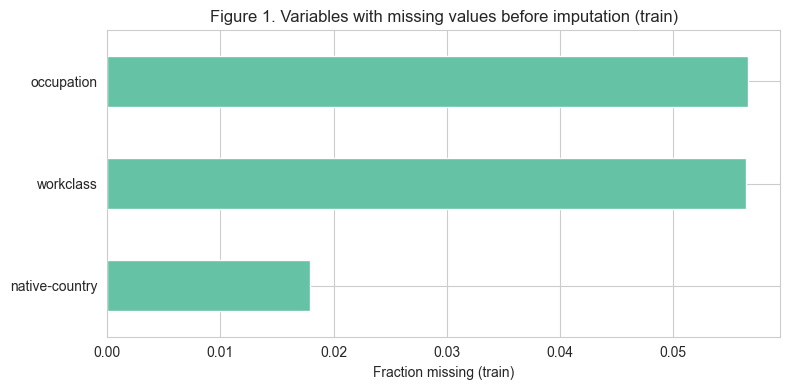

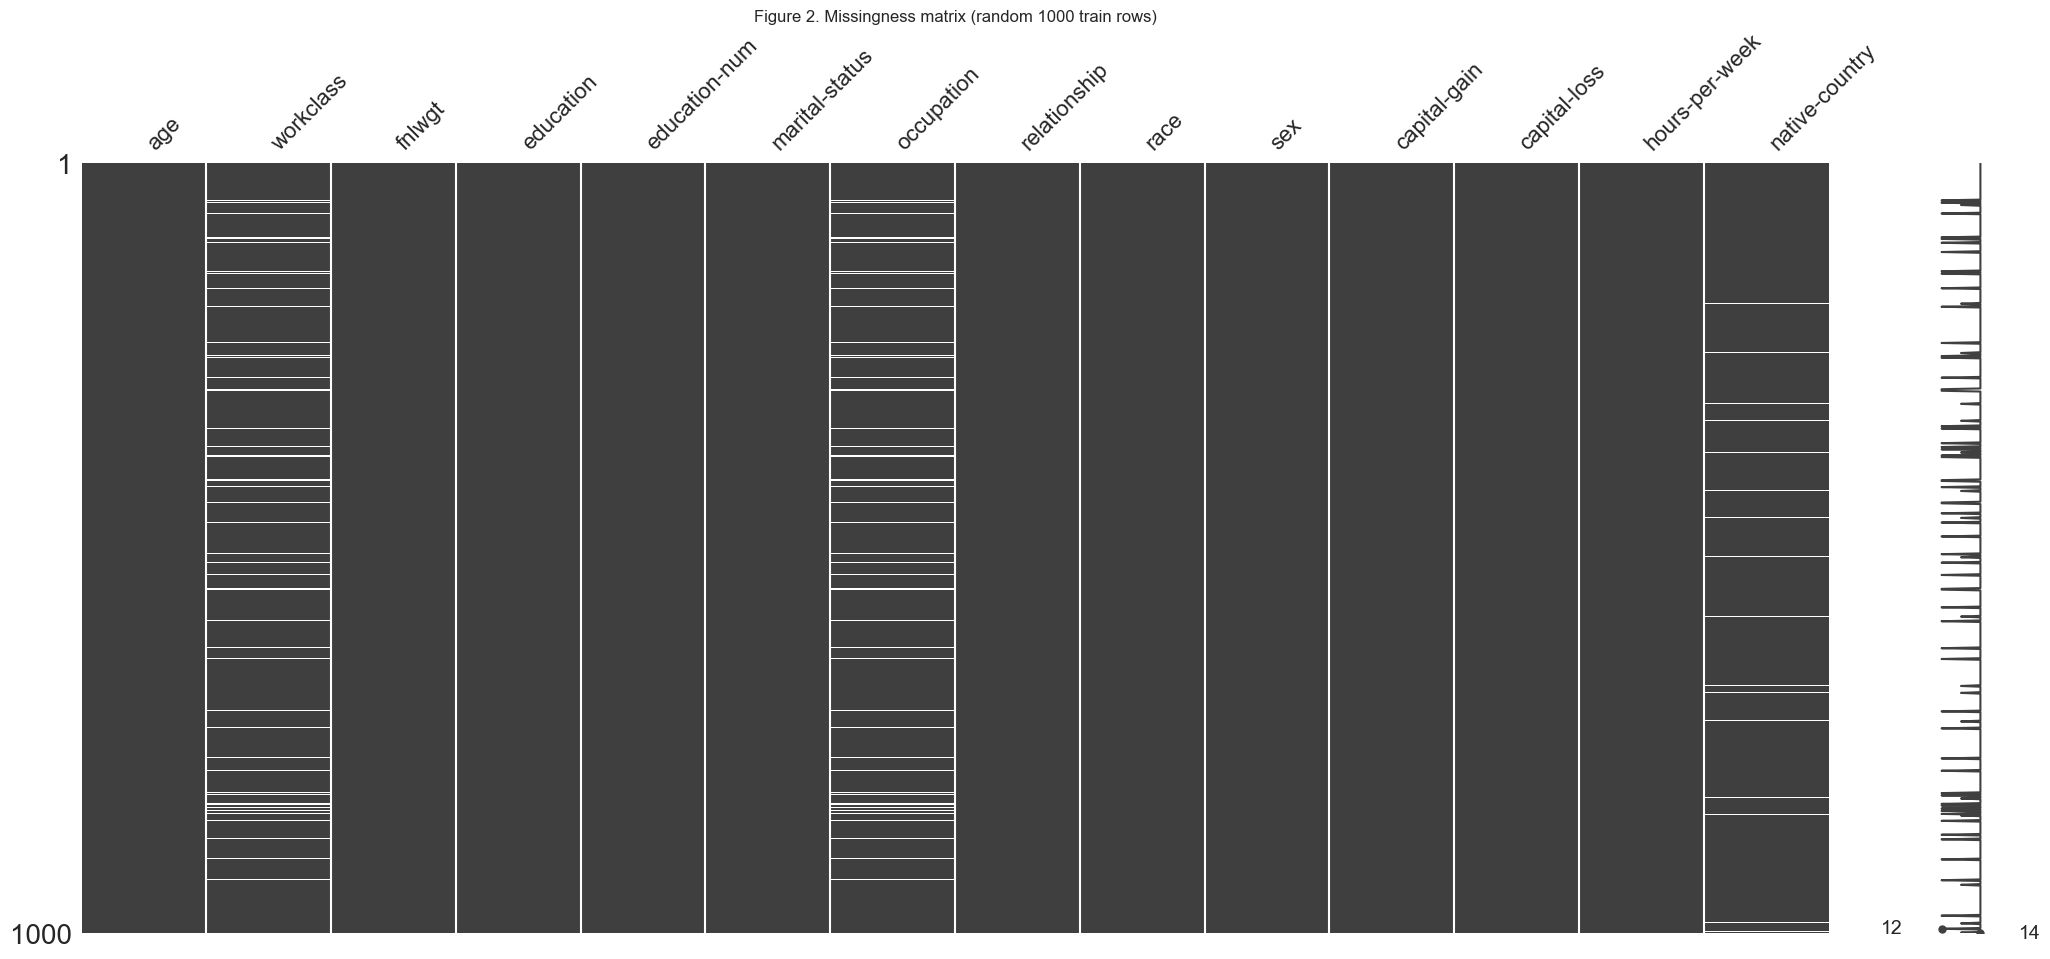

In [5]:
missing_frac = X_train.isna().mean().sort_values(ascending=False)
display(missing_frac[missing_frac > 0].to_frame("fraction_missing"))

plt.figure(figsize=(8, 4))
missing_frac[missing_frac > 0].sort_values().plot(kind="barh", color=sns.color_palette("Set2")[0])
plt.xlabel("Fraction missing (train)")
plt.title("Figure 1. Variables with missing values before imputation (train)")
plt.tight_layout()
plt.show()

# Missingness overview (same library stack as course labs)
msno.matrix(X_train.sample(min(1000, len(X_train)), random_state=42))
plt.title("Figure 2. Missingness matrix (random 1000 train rows)")
plt.show()


### 4.8 Duplicates

Lab exercises emphasize checking duplicate rows after cleaning.


In [6]:
# Formatted duplicate-row summary (checked on the predictor columns)
dup_tbl = pd.DataFrame({
    "n_rows": [len(X_train), len(X_test)],
    "duplicate_rows": [int(X_train.duplicated().sum()), int(X_test.duplicated().sum())],
}, index=["train", "test"])
dup_tbl["duplicate_frac"] = (dup_tbl["duplicate_rows"] / dup_tbl["n_rows"]).round(5)
display(dup_tbl)


,n_rows,duplicate_rows,duplicate_frac
train,32561,25,0.00077
test,16281,6,0.00037


### 4.9 Exploratory analysis

We mirror **Lab 5** themes: grouped comparisons and multivariate plots among quantitative variables (**Figures 3–5**). A full `pairplot` on tens of thousands of rows is slow; we plot a **random subsample** for visualization only.


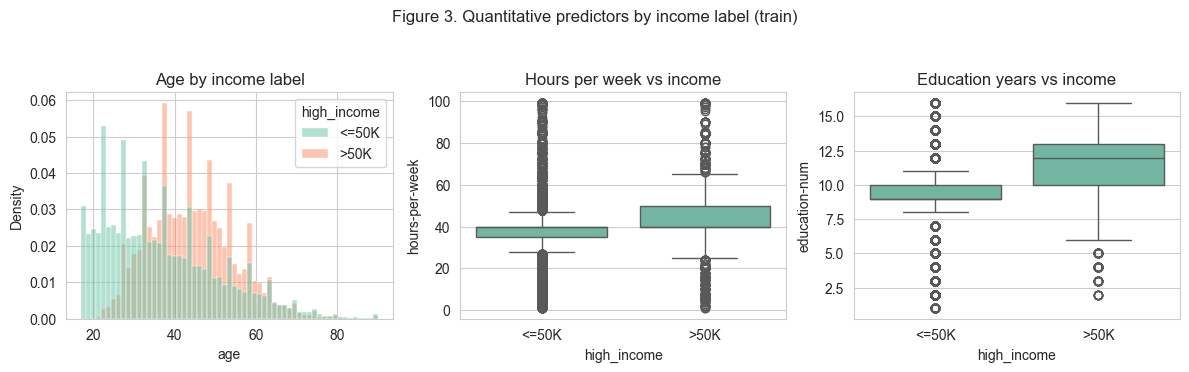

In [7]:
eda = train_df.copy()
eda["high_income"] = encode_target(eda["income"]).map({0: "<=50K", 1: ">50K"})

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

sns.histplot(data=eda, x="age", hue="high_income", stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Age by income label")

sns.boxplot(data=eda, x="high_income", y="hours-per-week", ax=axes[1])
axes[1].set_title("Hours per week vs income")

sns.boxplot(data=eda, x="high_income", y="education-num", ax=axes[2])
axes[2].set_title("Education years vs income")

fig.suptitle("Figure 3. Quantitative predictors by income label (train)", y=1.05)
plt.tight_layout()
plt.show()


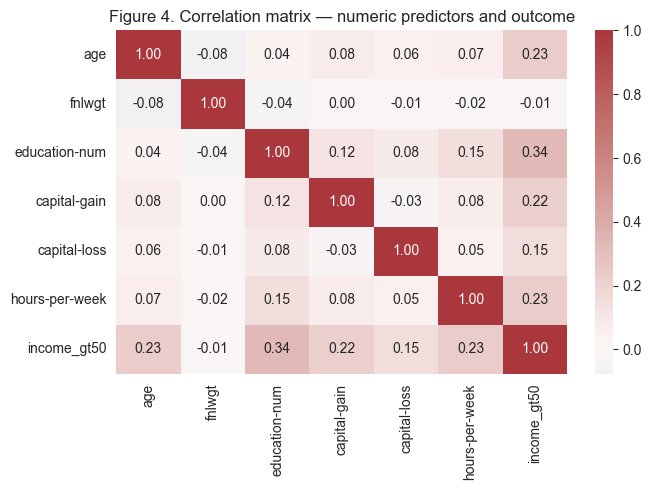

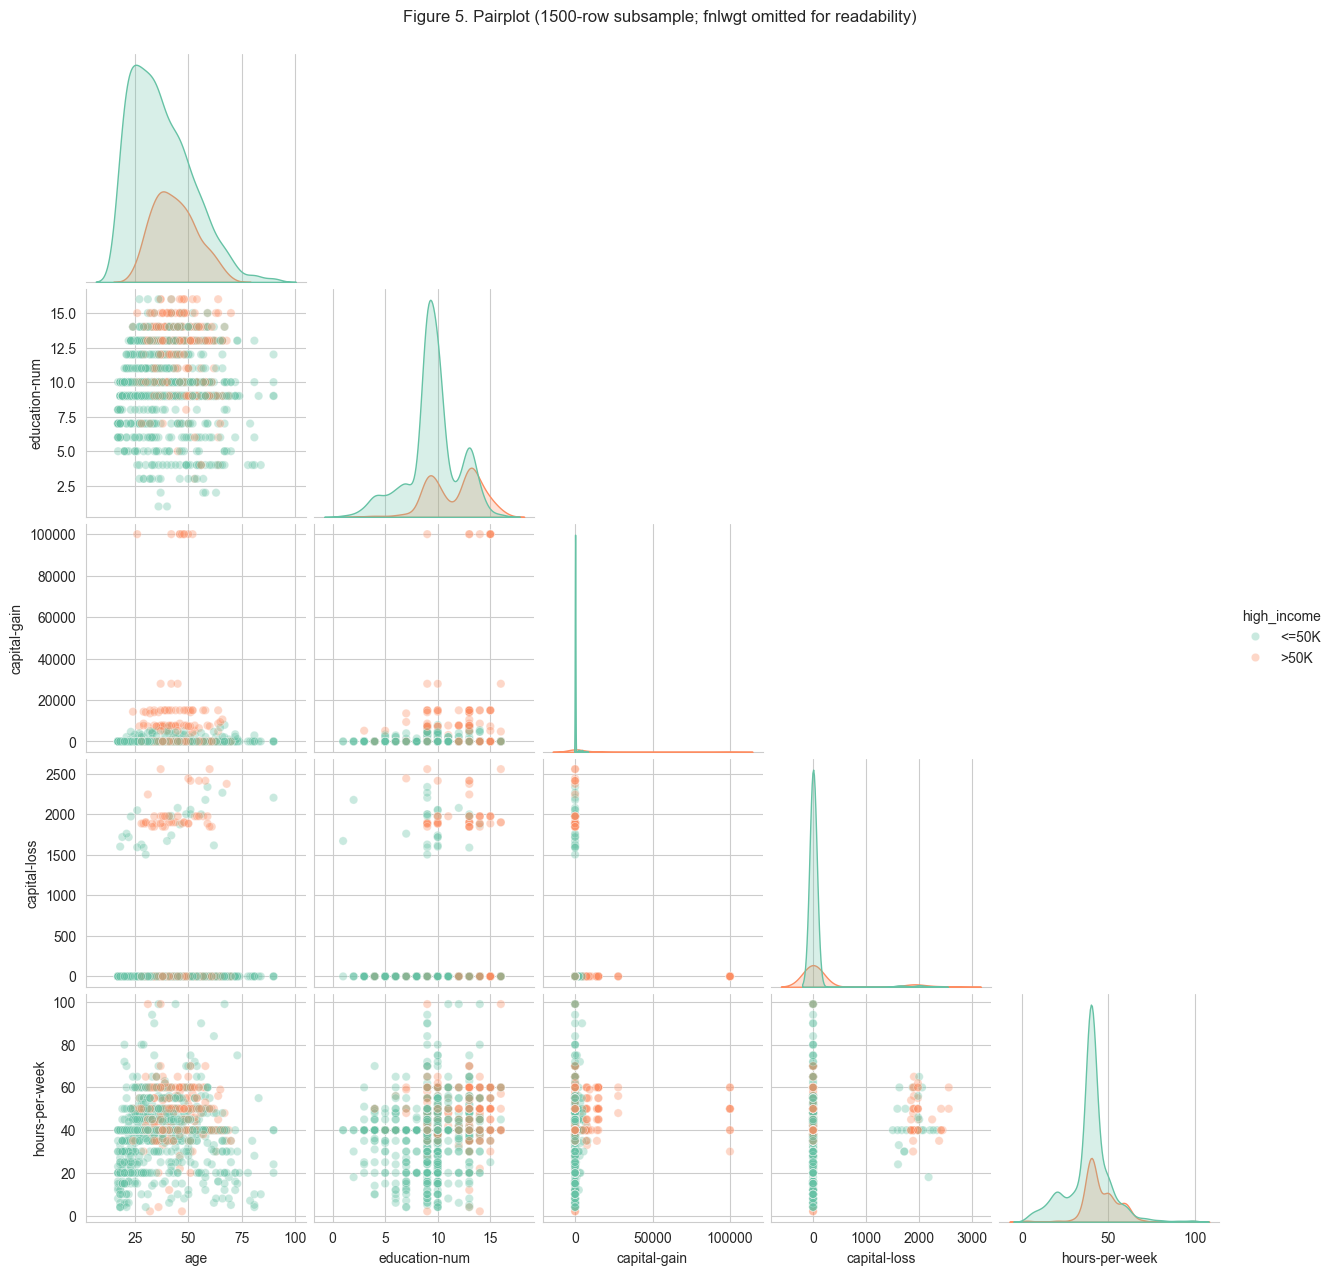

In [8]:
num_eda = train_df[NUMERIC].copy()
num_eda["income_gt50"] = y_train.values
corr_matrix = num_eda.corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Figure 4. Correlation matrix — numeric predictors and outcome")
plt.tight_layout()
plt.show()

sample = eda.sample(n=min(1500, len(eda)), random_state=42)
pair_vars = [c for c in NUMERIC if c != "fnlwgt"]
g = sns.pairplot(sample, vars=pair_vars, hue="high_income", corner=True, diag_kind="kde", plot_kws={"alpha": 0.35})
g.figure.suptitle("Figure 5. Pairplot (1500-row subsample; fnlwgt omitted for readability)", y=1.02)
plt.show()


In the exploratory plots, people labeled **>50K** tend to report **more hours per week** and **more years of education** on average than those labeled **<=50K**, while **age** overlaps heavily between groups but shifts somewhat toward older workers among higher earners. The correlation heatmap aligns with that story: **education-num** and **hours-per-week** have clearer positive association with the binary high-income indicator than variables like **capital-gain**, which are sparse but can spike for some rows. The pairplot on a subsample is noisy, yet it reinforces that separation between labels is gradual rather than a single clean cutoff in one variable alone.

---

## 5. Results

### 5.0 Majority-class baseline

Roughly **76%** of test rows are **<=50K**. A classifier that always predicts **<=50K** therefore gets about **76.4%** accuracy without learning anything. Any serious model should beat that by a clear margin.

### 5.1 Pipelines

We build two pipelines that share the same imputation and one-hot encoding for categoricals. Logistic regression **additionally scales** numeric inputs; the forest sees **imputed but unscaled** numeric columns, which is standard because tree splits are scale-invariant.


In [9]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, NUMERIC),
        ("cat", categorical_pipe, CATEGORICAL),
    ]
)

log_reg = Pipeline(
    steps=[
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=2000, random_state=42, solver="lbfgs")),
    ]
)

log_reg.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

Logistic regression — per-class classification report


,precision,recall,f1-score,support
<=50K,0.880,0.932,0.905,12435.000
>50K,0.728,0.587,0.650,3846.000
accuracy,0.851,0.851,0.851,0.851
macro avg,0.804,0.760,0.778,16281.000
weighted avg,0.844,0.851,0.845,16281.000


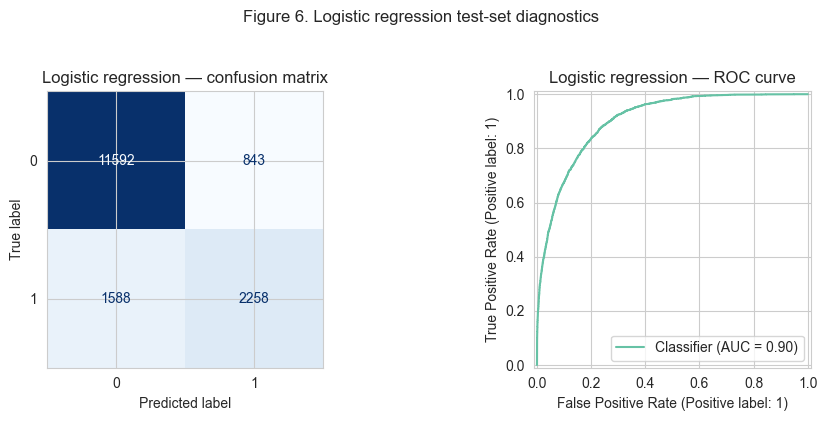

In [10]:
def evaluate_model(name: str, model, X_te, y_te, fig_no: int) -> dict:
    """Score a fitted pipeline on the test fold.

    Returns a metrics dict (for the Section 5.2 comparison table), shows the
    per-class classification report as a formatted DataFrame (not a raw console
    dump), and plots the confusion matrix and ROC curve side by side.
    """
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_te, pred)
    auc = roc_auc_score(y_te, proba)

    # classification_report as a tidy, rounded table
    report = classification_report(
        y_te, pred, target_names=["<=50K", ">50K"], output_dict=True
    )
    report_tbl = pd.DataFrame(report).T.round(3)
    print(f"{name} — per-class classification report")
    display(report_tbl)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, pred, ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{name} — confusion matrix")
    RocCurveDisplay.from_predictions(y_te, proba, ax=axes[1])
    axes[1].set_title(f"{name} — ROC curve")
    fig.suptitle(f"Figure {fig_no}. {name} test-set diagnostics", y=1.04)
    plt.tight_layout()
    plt.show()

    return {
        "model": name,
        "accuracy": round(acc, 4),
        "roc_auc": round(auc, 4),
        "precision_>50K": round(report[">50K"]["precision"], 3),
        "recall_>50K": round(report[">50K"]["recall"], 3),
        "f1_>50K": round(report[">50K"]["f1-score"], 3),
    }


logit_metrics = evaluate_model("Logistic regression", log_reg, X_test, y_test, fig_no=6)


Random forest — per-class classification report


,precision,recall,f1-score,support
<=50K,0.886,0.924,0.904,12435.000
>50K,0.714,0.614,0.660,3846.000
accuracy,0.851,0.851,0.851,0.851
macro avg,0.800,0.769,0.782,16281.000
weighted avg,0.845,0.851,0.847,16281.000


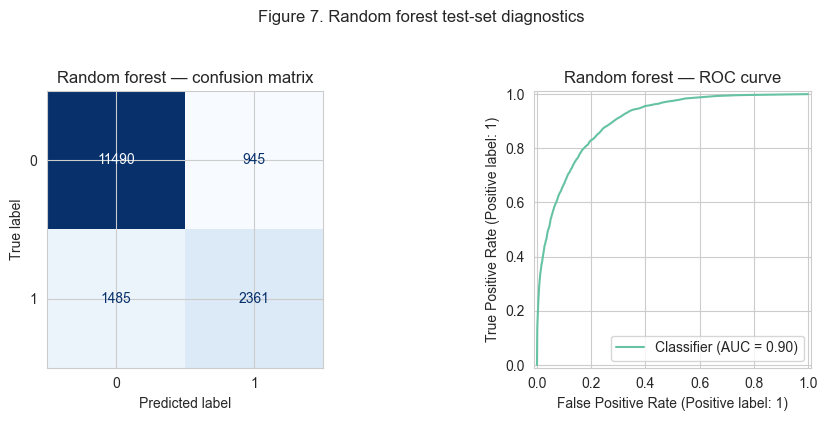

In [11]:
rf_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), NUMERIC),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            CATEGORICAL,
        ),
    ]
)

rf_clf = Pipeline(
    steps=[
        ("prep", rf_preprocess),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_clf.fit(X_train, y_train)
rf_metrics = evaluate_model("Random forest", rf_clf, X_test, y_test, fig_no=7)


In [12]:
# Section 5.2 — single formatted table comparing both models against the baseline.
# Table 1 below is referenced in the discussion that follows.
maj_rate = max(y_test.mean(), 1 - y_test.mean())
baseline_metrics = {
    "model": "Majority-class baseline",
    "accuracy": round(maj_rate, 4),
    "roc_auc": 0.5,            # a constant predictor has no discrimination
    "precision_>50K": 0.0,
    "recall_>50K": 0.0,
    "f1_>50K": 0.0,
}

comparison = (
    pd.DataFrame([baseline_metrics, logit_metrics, rf_metrics])
    .set_index("model")
)
print("Table 1. Test-set performance comparison (positive class = income > $50K)")
display(comparison.style.format("{:.4f}").background_gradient(cmap="Greens", subset=["accuracy", "roc_auc"]))

Table 1. Test-set performance comparison (positive class = income > $50K)


,accuracy,roc_auc,precision_>50K,recall_>50K,f1_>50K
model,,,,,
Majority-class baseline,0.7638,0.5000,0.0000,0.0000,0.0000
Logistic regression,0.8507,0.9038,0.7280,0.5870,0.6500
Random forest,0.8507,0.9008,0.7140,0.6140,0.6600


### 5.2 Model comparison

**Table 1** collects the headline metrics. On this fixed split, **logistic regression** and the **random forest** achieve **similar test accuracy** near **85%**, both well above the **76.4%** majority baseline. **ROC-AUC** is high for both; in our run the logit is slightly ahead on AUC while the forest is not automatically better despite extra flexibility. For the minority **>50K** class, the per-class report tables and the confusion matrices in **Figures 6 and 7** show that errors are mostly false negatives (predict <=50K when truth is >50K), which is expected when positives are rare.

The forest adds hyperparameters and interpretation cost. Here it does not clearly dominate the logit, so a course-appropriate takeaway is that **a simple linear probability model already captures most of the predictable signal** on this benchmark, and fancier methods need to earn their keep on validation metrics you care about.

---

## 6. Conclusion

This notebook reproduced a standard Adult workflow: clean missing tokens, explore associations, then fit and compare classifiers on the official test fold. **Education and hours worked** show consistent separation in exploratory views; formal models lift accuracy by roughly **9 percentage points** over always guessing the majority class. Results remain **associational**: they describe labels in a 1994-era extract, not causal effects of changing education or occupation today.

Limitations include **historical data**, **duplicate education encodings**, using **`fnlwgt` as a feature** even though it is really a survey weight, and **class imbalance** that makes naive accuracy easy to inflate. A natural extension would be **probability calibration** or **cost-sensitive thresholds** if false negatives for >50K are more expensive than false positives.

---

## 7. References

1. Becker, B., & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20
2. Kohavi, R. (1996). Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid. In *Proceedings of KDD-96* (secondary citation from UCI `adult.names` notes).
3. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.

---
